Descriptive statistics

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from sklearn.linear_model import LinearRegression

In [5]:
df = pd.read_csv("Housing_clean.csv")

In [6]:
df.head()

,house_id,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [7]:
print("=== MEAN ===")
print(df.mean())

print("\n=== MEDIAN ===")
print(df.median())

print("\n=== MODE ===")
print(df.mode().iloc[0])

=== MEAN ===
house_id            2.720000e+02
price               4.766729e+06
area                5.150541e+03
bedrooms            2.965138e+00
bathrooms           1.286239e+00
stories             1.805505e+00
mainroad            8.587156e-01
guestroom           1.779817e-01
basement            3.504587e-01
hotwaterheating     4.587156e-02
airconditioning     3.155963e-01
parking             6.935780e-01
prefarea            2.348624e-01
furnishingstatus    9.302752e-01
dtype: float64

=== MEDIAN ===
house_id                272.0
price               4340000.0
area                   4600.0
bedrooms                  3.0
bathrooms                 1.0
stories                   2.0
mainroad                  1.0
guestroom                 0.0
basement                  0.0
hotwaterheating           0.0
airconditioning           0.0
parking                   0.0
prefarea                  0.0
furnishingstatus          1.0
dtype: float64

=== MODE ===
house_id                  0.0
price          

In [8]:
print("=== VARIANCE ===")
print(df.var())

print("\n=== STANDARD DEVIATION ===")
print(df.std())

print("\n=== RANGE ===")
print(df.max() - df.min())

=== VARIANCE ===
house_id            2.479750e+04
price               3.498544e+12
area                4.709512e+06
bedrooms            5.447383e-01
bathrooms           2.524757e-01
stories             7.525432e-01
mainroad            1.215461e-01
guestroom           1.465731e-01
basement            2.280559e-01
hotwaterheating     4.384781e-02
airconditioning     2.163923e-01
parking             7.423300e-01
prefarea            1.800324e-01
furnishingstatus    5.796883e-01
dtype: float64

=== STANDARD DEVIATION ===
house_id            1.574722e+02
price               1.870440e+06
area                2.170141e+03
bedrooms            7.380639e-01
bathrooms           5.024696e-01
stories             8.674925e-01
mainroad            3.486347e-01
guestroom           3.828487e-01
basement            4.775519e-01
hotwaterheating     2.093987e-01
airconditioning     4.651799e-01
parking             8.615858e-01
prefarea            4.243022e-01
furnishingstatus    7.613727e-01
dtype: float64



In [9]:
print("=== SKEWNESS ===")
print(df.skew())

print("\n=== KURTOSIS ===")
print(df.kurt())

=== SKEWNESS ===
house_id            0.000000
price               1.212239
area                1.321188
bedrooms            0.495684
bathrooms           1.589264
stories             1.082088
mainroad           -2.065410
guestroom           1.688419
basement            0.628590
hotwaterheating     4.353428
airconditioning     0.795748
parking             0.842062
prefarea            1.254361
furnishingstatus    0.117666
dtype: float64

=== KURTOSIS ===
house_id            -1.200000
price                1.960130
area                 2.751480
bedrooms             0.728323
bathrooms            2.164856
stories              0.679404
mainroad             2.274252
guestroom            0.853877
basement            -1.610800
hotwaterheating     17.014764
airconditioning     -1.371834
parking             -0.573063
prefarea            -0.428162
furnishingstatus    -1.265292
dtype: float64


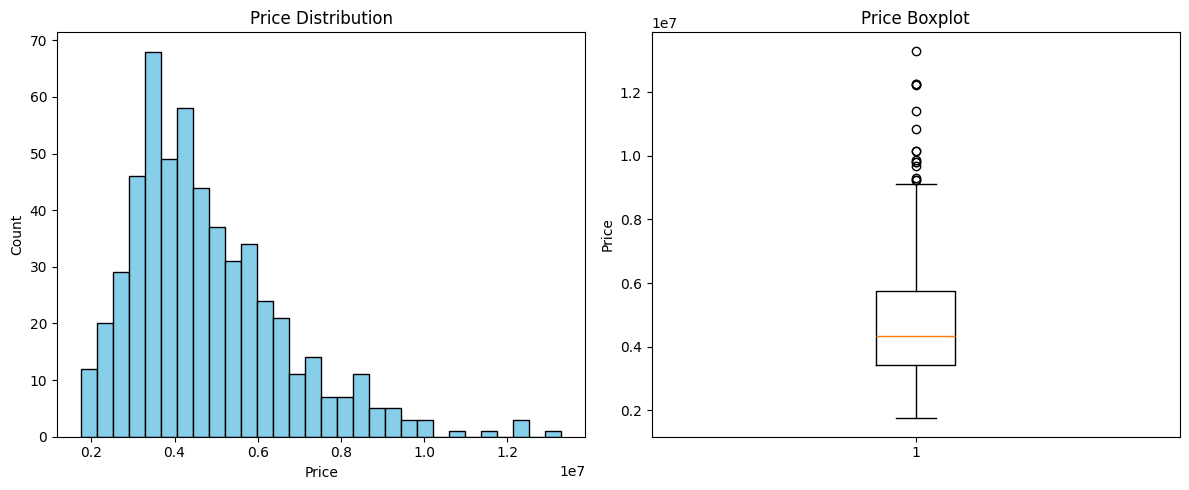

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
ax[0].hist(df['price'], bins=30, color='skyblue', edgecolor='black')
ax[0].set_title('Price Distribution')
ax[0].set_xlabel('Price')
ax[0].set_ylabel('Count')

# Boxplot
ax[1].boxplot(df['price'])
ax[1].set_title('Price Boxplot')
ax[1].set_ylabel('Price')

plt.tight_layout()
plt.show();

Normal distribution test

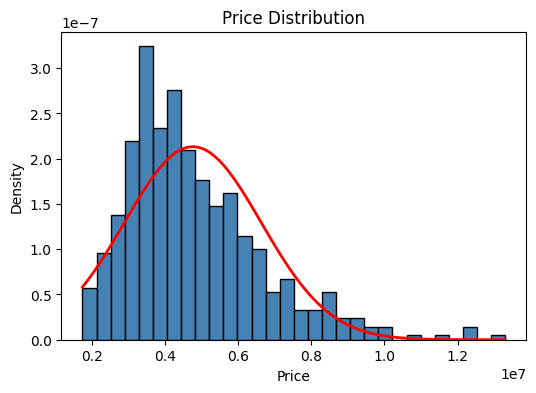

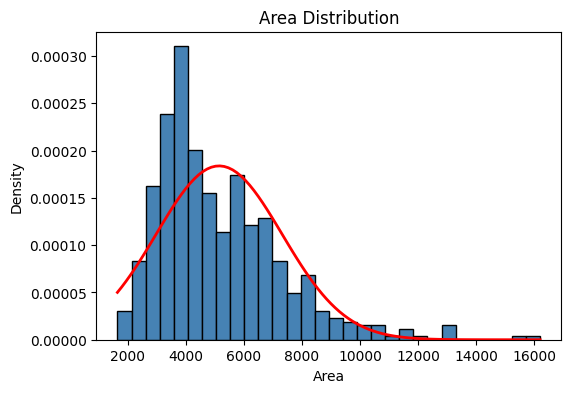

In [11]:
# Price
plt.figure(figsize=(6, 4))
mu, std = df['price'].mean(), df['price'].std()
x = np.linspace(df['price'].min(), df['price'].max(), 100)
plt.hist(df['price'], bins=30, color='steelblue', edgecolor='black', density=True)
plt.plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()

# Area
plt.figure(figsize=(6, 4))
mu, std = df['area'].mean(), df['area'].std()
x = np.linspace(df['area'].min(), df['area'].max(), 100)
plt.hist(df['area'], bins=30, color='steelblue', edgecolor='black', density=True)
plt.plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2)
plt.title('Area Distribution')
plt.xlabel('Area')
plt.ylabel('Density')
plt.show()

Shapiro-Wilk Test

In [12]:
from scipy.stats import shapiro

print("=== NORMALITY TEST ===\n")

stat, p = shapiro(df['price'])
print(f"Price: p-value = {p:.4f}")

stat, p = shapiro(df['area'])
print(f"Area: p-value = {p:.4f}")

stat, p = shapiro(df['bedrooms'])
print(f"Bedrooms: p-value = {p:.4f}")

stat, p = shapiro(df['bathrooms'])
print(f"Bathrooms: p-value = {p:.4f}")

=== NORMALITY TEST ===

Price: p-value = 0.0000
Area: p-value = 0.0000
Bedrooms: p-value = 0.0000
Bathrooms: p-value = 0.0000


QQ Plot

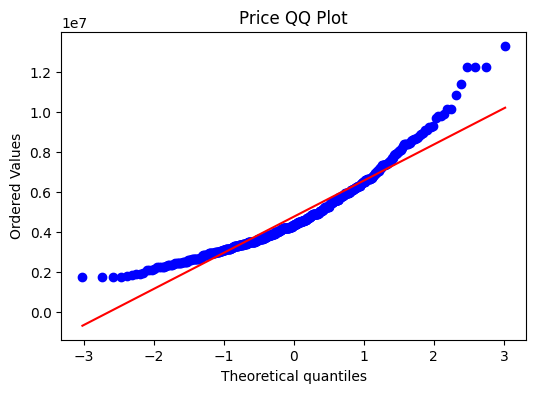

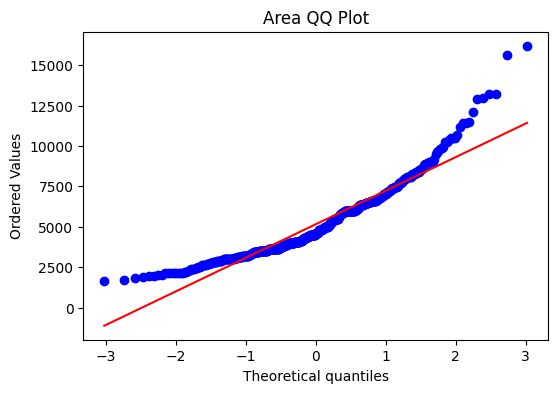

In [13]:
from scipy import stats

# Price QQ Plot
plt.figure(figsize=(6, 4))
stats.probplot(df['price'], dist="norm", plot=plt)
plt.title('Price QQ Plot')
plt.show()

# Area QQ Plot
plt.figure(figsize=(6, 4))
stats.probplot(df['area'], dist="norm", plot=plt)
plt.title('Area QQ Plot')
plt.show()

Log Transformation

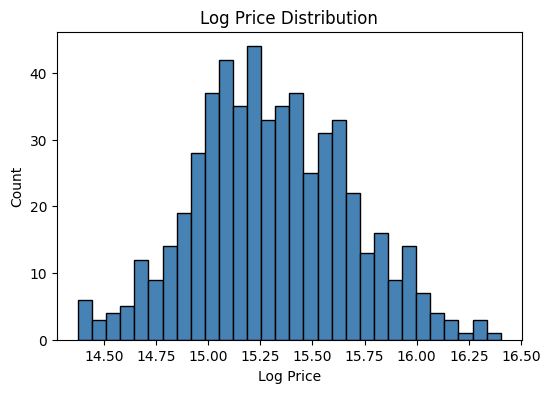

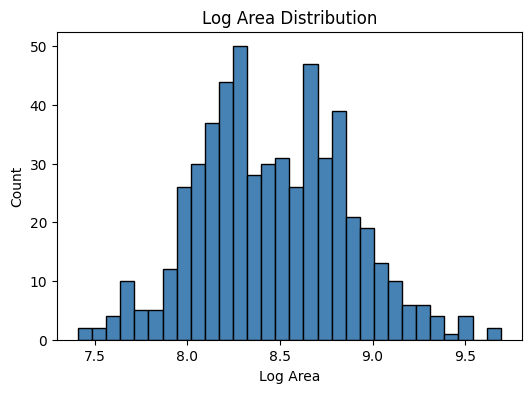

In [14]:
# Log Price
plt.figure(figsize=(6, 4))
plt.hist(np.log(df['price']), bins=30, color='steelblue', edgecolor='black')
plt.title('Log Price Distribution')
plt.xlabel('Log Price')
plt.ylabel('Count')
plt.show()

# Log Area
plt.figure(figsize=(6, 4))
plt.hist(np.log(df['area']), bins=30, color='steelblue', edgecolor='black')
plt.title('Log Area Distribution')
plt.xlabel('Log Area')
plt.ylabel('Count')
plt.show()

Hypothesis Testing — Housing Dataset

Test 1 — T-test: Does Airconditioning affect Price?

In [15]:
ac_yes = df[df['airconditioning'] == 1]['price']
ac_no = df[df['airconditioning'] == 0]['price']

stat, p = ttest_ind(ac_yes, ac_no)
print(f"T-test (Airconditioning vs Price)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - AC significantly affects price")
else:
    print("❌ Fail to reject H0 - AC has no significant effect")

T-test (Airconditioning vs Price)
p-value = 0.0000
✅ Reject H0 - AC significantly affects price


Test 2 — T-test: Does Mainroad affect Price?

In [16]:
main_yes = df[df['mainroad'] == 1]['price']
main_no = df[df['mainroad'] == 0]['price']

stat, p = ttest_ind(main_yes, main_no)
print(f"\nT-test (Mainroad vs Price)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - Mainroad significantly affects price")
else:
    print("❌ Fail to reject H0 - Mainroad has no significant effect")


T-test (Mainroad vs Price)
p-value = 0.0000
✅ Reject H0 - Mainroad significantly affects price


Test 3 — ANOVA: Does Furnishing Status affect Price?

Here furnishing has 3 groups so i am using ANOVA

In [18]:
unfurnished = df[df['furnishingstatus'] == 0]['price']
semi = df[df['furnishingstatus'] == 1]['price']
furnished = df[df['furnishingstatus'] == 2]['price']

stat, p = f_oneway(unfurnished, semi, furnished)
print(f"\nANOVA (Furnishing Status vs Price)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - Furnishing status significantly affects price")
else:
    print("❌ Fail to reject H0 - Furnishing status has no significant effect")


ANOVA (Furnishing Status vs Price)
p-value = 0.0000
✅ Reject H0 - Furnishing status significantly affects price


Test 4 — ANOVA: Does Number of Bedrooms affect Price?

In [19]:
groups = [df[df['bedrooms'] == i]['price'] for i in df['bedrooms'].unique()]

stat, p = f_oneway(*groups)
print(f"\nANOVA (Bedrooms vs Price)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - Bedrooms significantly affects price")
else:
    print("❌ Fail to reject H0 - Bedrooms has no significant effect")


ANOVA (Bedrooms vs Price)
p-value = 0.0000
✅ Reject H0 - Bedrooms significantly affects price


Test 5 — T-test: Does Basement affect Price?

In [20]:
basement_yes = df[df['basement'] == 1]['price']
basement_no = df[df['basement'] == 0]['price']

stat, p = ttest_ind(basement_yes, basement_no)
print(f"\nT-test (Basement vs Price)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - Basement significantly affects price")
else:
    print("❌ Fail to reject H0 - Basement has no significant effect")


T-test (Basement vs Price)
p-value = 0.0000
✅ Reject H0 - Basement significantly affects price


Chi-Square Test -- Categorical Relationships

In [22]:
# create contingency table
contingency = pd.crosstab(df['mainroad'], df['airconditioning'])
print(contingency)

# Run chi-square test
stat, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-Square Test (Mainroad vs Airconditioning)")
print(f"p-value = {p: .4f}")
if p < 0.05:
    print("✅ Reject H0 - Mainroad and Airconditioning are related")
else:
    print("❌ Fail to reject H0 - No relationship between them")

airconditioning    0    1
mainroad                 
0                 62   15
1                311  157

Chi-Square Test (Mainroad vs Airconditioning)
p-value =  0.0199
✅ Reject H0 - Mainroad and Airconditioning are related


Test — Is Prefarea related to Furnishing Status?

In [23]:
contingency2 = pd.crosstab(df['prefarea'], df['furnishingstatus'])
print(contingency2)

stat, p, dof, expected = chi2_contingency(contingency2)
print(f"\nChi-Square Test (Prefarea vs Furnishing Status)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - Prefarea and Furnishing Status are related")
else:
    print("❌ Fail to reject H0 - No relationship between them")

furnishingstatus    0    1   2
prefarea                      
0                 145  175  97
1                  33   52  43

Chi-Square Test (Prefarea vs Furnishing Status)
p-value = 0.0381
✅ Reject H0 - Prefarea and Furnishing Status are related


Correlation vs Causation

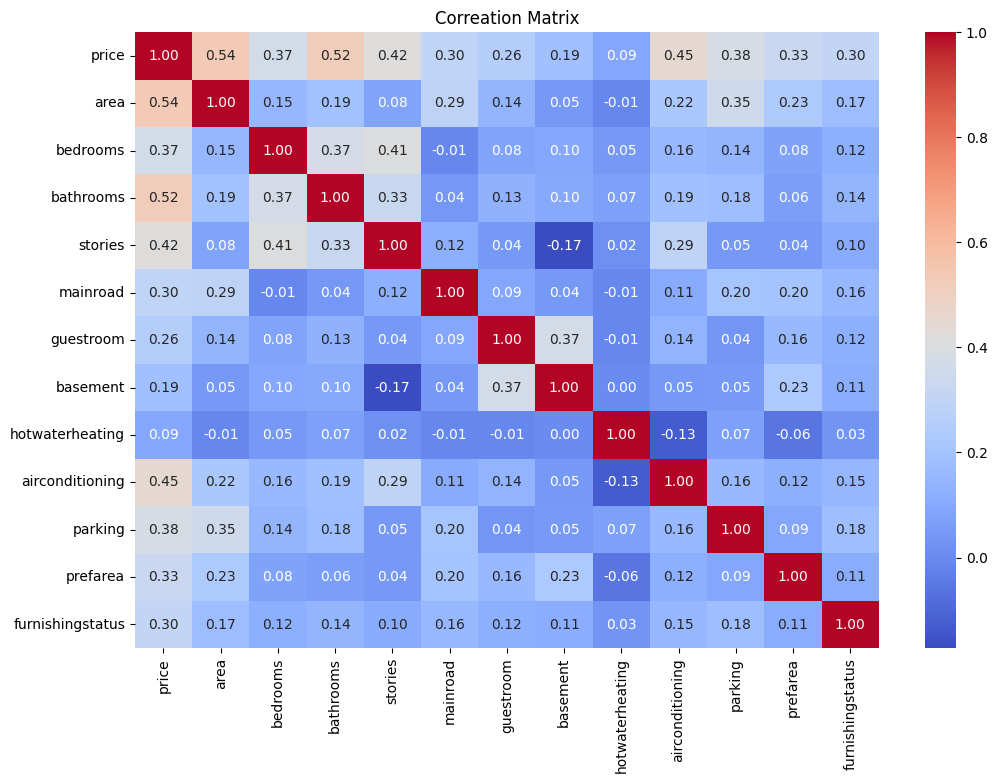

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correation Matrix')
plt.show()

In [ ]:
print(df.corr()['price'].sort_values(ascending=False))

price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
furnishingstatus    0.304721
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
Name: price, dtype: float64


: 

Confounding Variables

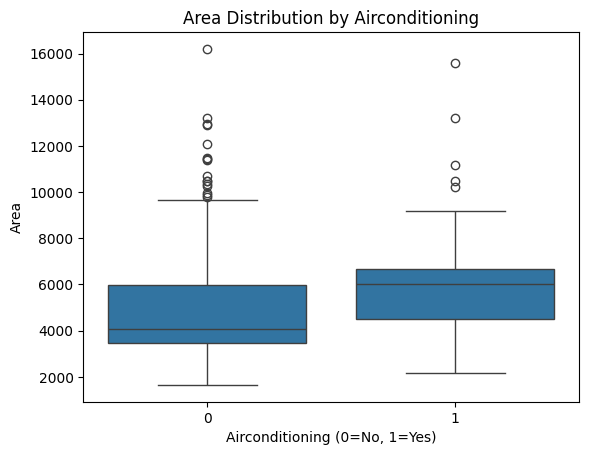

In [26]:
# Example: Does Ac alone explain price difference, or is area the real factor
sns.boxplot(x='airconditioning', y='area', data=df)
plt.title('Area Distribution by Airconditioning')
plt.xlabel('Airconditioning (0=No, 1=Yes)')
plt.ylabel('Area')
plt.show();

In [28]:
df.drop('house_id', axis=1, inplace=True)

In [30]:
# Multiple regression - controls for other features simultaneously

X = df[['area', 'bathrooms', 'airconditioning', 'stories']]
y = df['price']

model = LinearRegression()
model.fit(X, y)

print("Coefficients (effect of each feature, holding others constant):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

Coefficients (effect of each feature, holding others constant):
area: 346.08
bathrooms: 1214389.70
airconditioning: 969365.12
stories: 452355.97
